In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.8 MB/s eta 0:00:00


In [2]:
import os, glob, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict
from ultralytics import YOLO

# Paths - change the directory as needed
DATASET_ROOT = "/kaggle/input/datasets/sectumsemprra/sku-data"
WEIGHTS_PATH = "/kaggle/input/models/sectumsemprra/best/pytorch/version1/1/best.pt"

# Inference config
CONF      = 0.70
IOU       = 0.50
USE_TTA   = True

print(f"✅ Dataset  : {DATASET_ROOT}")
print(f"✅ Weights  : {WEIGHTS_PATH}")
print(f"✅ Conf     : {CONF}")
print(f"✅ TTA      : {USE_TTA}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Dataset  : /kaggle/input/datasets/sectumsemprra/sku-data
✅ Weights  : /kaggle/input/models/sectumsemprra/best/pytorch/version1/1/best.pt
✅ Conf     : 0.7
✅ TTA      : True


In [3]:
#Load class names
with open(f"{DATASET_ROOT}/data.yaml") as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg["names"]
NUM_CLASSES = cfg["nc"]

print(f"✅ Classes  : {NUM_CLASSES}")
print(f"✅ Names    : {CLASS_NAMES}")

✅ Classes  : 76
✅ Names    : ['q1', 'q10', 'q100', 'q103', 'q106', 'q109', 'q112', 'q115', 'q118', 'q121', 'q13', 'q130', 'q133', 'q136', 'q142', 'q145', 'q148', 'q151', 'q157', 'q16', 'q163', 'q169', 'q175', 'q178', 'q184', 'q187', 'q19', 'q190', 'q193', 'q196', 'q199', 'q202', 'q211', 'q214', 'q22', 'q220', 'q229', 'q232', 'q247', 'q25', 'q250', 'q256', 'q262', 'q265', 'q268', 'q271', 'q274', 'q280', 'q286', 'q289', 'q291', 'q293', 'q299', 'q31', 'q34', 'q37', 'q4', 'q40', 'q46', 'q49', 'q52', 'q55', 'q58', 'q61', 'q64', 'q67', 'q7', 'q70', 'q73', 'q76', 'q79', 'q82', 'q88', 'q91', 'q94', 'q97']


In [4]:
# Fix yaml paths
cfg["train"] = f"{DATASET_ROOT}/train/images"
cfg["val"]   = f"{DATASET_ROOT}/valid/images"
cfg["test"]  = f"{DATASET_ROOT}/test/images"

fixed_yaml = "/kaggle/working/data.yaml"
with open(fixed_yaml, "w") as f:
    yaml.dump(cfg, f)

print(f"✅ Fixed yaml saved to {fixed_yaml}")

✅ Fixed yaml saved to /kaggle/working/data.yaml


In [5]:
model = YOLO(WEIGHTS_PATH)
print("✅ Model loaded successfully")

✅ Model loaded successfully


In [6]:
# evaluation on test set

val = model.val(
    data    = fixed_yaml,
    conf    = CONF,
    iou     = IOU,
    augment = USE_TTA,
    split   = "test",
    verbose = False,
)

p  = val.box.mp
r  = val.box.mr
f1 = 2 * p * r / (p + r + 1e-9)

print(f"{'='*50}")
print(f"   MODEL PERFORMANCE ON TEST SET")
print(f"{'='*50}")
print(f"  Confidence Threshold : {CONF}")
print(f"  TTA                  : {USE_TTA}")
print(f"  Precision            : {p*100:.1f}%")
print(f"  Recall               : {r*100:.1f}%  (baseline: 67.6%)")
print(f"  F1 Score             : {f1*100:.1f}%")
print(f"  mAP50                : {val.box.map50*100:.1f}%")
print(f"  Improvement          : +{(r-0.676)*100:.1f}pp over baseline")
print(f"{'='*50}")

Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
YOLO11x summary (fused): 191 layers, 56,914,804 parameters, 0 gradients, 194.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 34.0±6.1 MB/s, size: 84.2 KB)
val: Scanning /kaggle/input/datasets/sectumsemprra/sku-data/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 425.4it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/sectumsemprra/sku-data/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.6it/s 1.9s1.0s
                   all         35        145      0.784      0.737      0.779      0.456
Speed: 4.2ms preprocess, 24.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
   MODEL PERFORMANCE ON TEST SET
  Confidence Threshold : 0.7
  TTA                  : True
  Precision            : 78.4

In [7]:
test_images = glob.glob(f"{DATASET_ROOT}/test/images/*.jpg") + \
              glob.glob(f"{DATASET_ROOT}/test/images/*.png")

print(f"Running inference on {len(test_images)} test images...")

class_detection_counts = defaultdict(int)
total_detections = 0

for img_path in test_images:
    results = model.predict(
        source  = img_path,
        conf    = CONF,
        iou     = IOU,
        augment = USE_TTA,
        verbose = False,
    )
    for r in results:
        if r.boxes is not None:
            for cls_id in r.boxes.cls.cpu().numpy():
                class_detection_counts[int(cls_id)] += 1
                total_detections += 1

print(f"✅ Done!")
print(f"   Total detections : {total_detections}")
print(f"   Ground truth     : 145")
print(f"   Difference       : {total_detections - 145:+d}")
print(f"   Unique SKUs      : {len(class_detection_counts)}")

Running inference on 35 test images...
✅ Done!
   Total detections : 143
   Ground truth     : 145
   Difference       : -2
   Unique SKUs      : 26


In [8]:
sos_data = []
for cls_id, count in class_detection_counts.items():
    cls_name  = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"class_{cls_id}"
    share_pct = (count / total_detections) * 100
    sos_data.append({
        "class_id"  : cls_id,
        "class_name": cls_name,
        "count"     : count,
        "share_pct" : round(share_pct, 2),
    })

df_sos = pd.DataFrame(sos_data).sort_values("share_pct", ascending=False).reset_index(drop=True)
df_sos["rank"] = df_sos.index + 1

print(f"\n{'Rank':>4} | {'SKU':<10} | {'Detections':>10} | {'Share %':>8}")
print("-" * 42)
for _, row in df_sos.iterrows():
    print(f"{row['rank']:>4} | {row['class_name']:<10} | {row['count']:>10} | {row['share_pct']:>7.2f}%")


Rank | SKU        | Detections |  Share %
------------------------------------------
   1 | q214       |         19 |   13.29%
   2 | q280       |         18 |   12.59%
   3 | q64        |         17 |   11.89%
   4 | q293       |         13 |    9.09%
   5 | q193       |         12 |    8.39%
   6 | q13        |         11 |    7.69%
   7 | q121       |          7 |    4.90%
   8 | q289       |          5 |    3.50%
   9 | q7         |          4 |    2.80%
  10 | q61        |          4 |    2.80%
  11 | q286       |          4 |    2.80%
  12 | q142       |          3 |    2.10%
  13 | q106       |          3 |    2.10%
  14 | q199       |          3 |    2.10%
  15 | q265       |          3 |    2.10%
  16 | q202       |          3 |    2.10%
  17 | q109       |          3 |    2.10%
  18 | q268       |          2 |    1.40%
  19 | q91        |          2 |    1.40%
  20 | q184       |          1 |    0.70%
  21 | q25        |          1 |    0.70%
  22 | q31        |          1 |

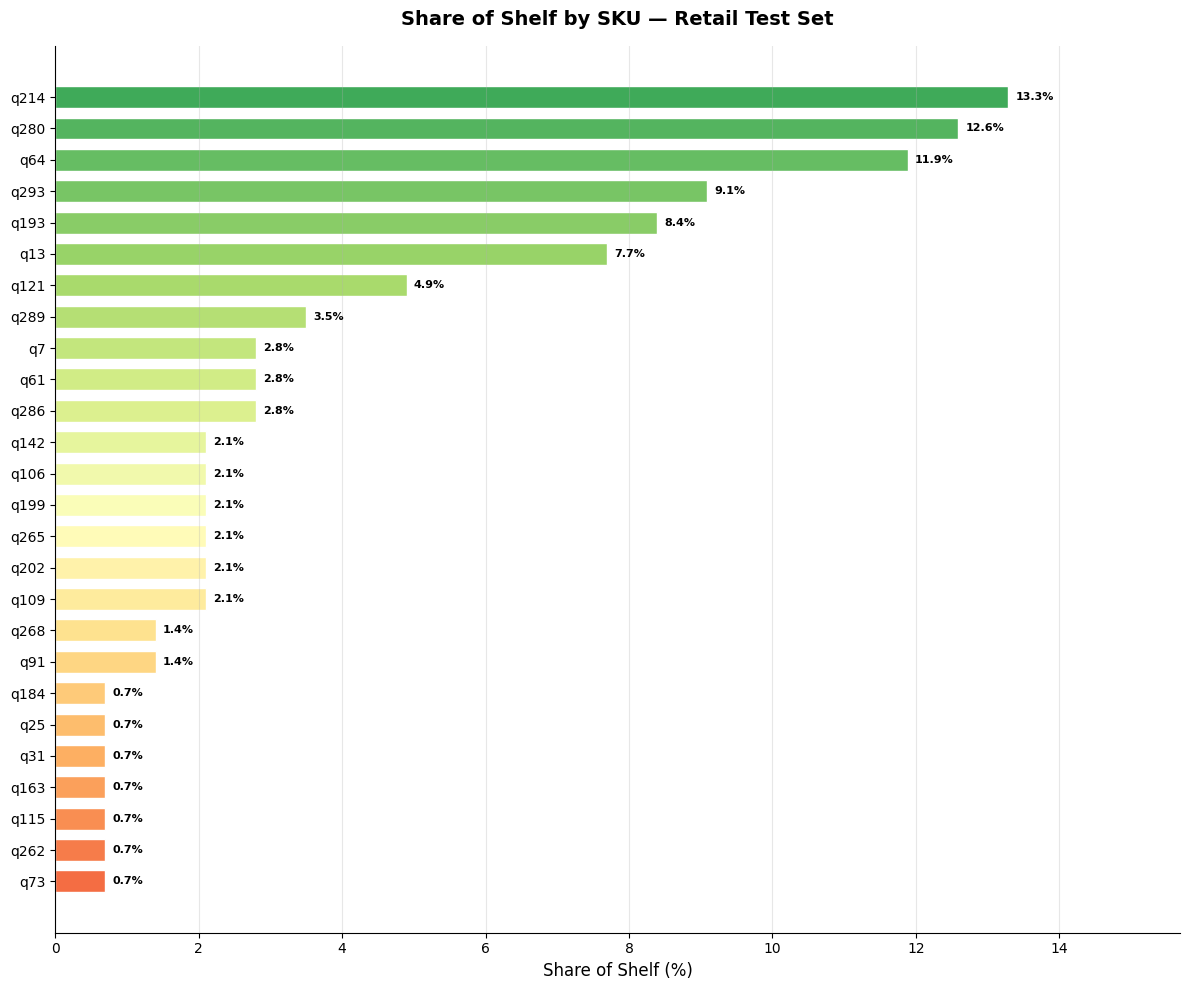

In [9]:
fig, ax = plt.subplots(figsize=(12, 10))

colors = cm.RdYlGn(np.linspace(0.85, 0.2, len(df_sos)))
bars   = ax.barh(df_sos["class_name"][::-1], df_sos["share_pct"][::-1],
                 color=colors[::-1], edgecolor="white", height=0.7)

for bar, val in zip(bars, df_sos["share_pct"][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8, fontweight="bold")

ax.set_xlabel("Share of Shelf (%)", fontsize=12)
ax.set_title("Share of Shelf by SKU — Retail Test Set",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, df_sos["share_pct"].max() * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("share_of_shelf_bar.png", dpi=150, bbox_inches="tight")
plt.show()

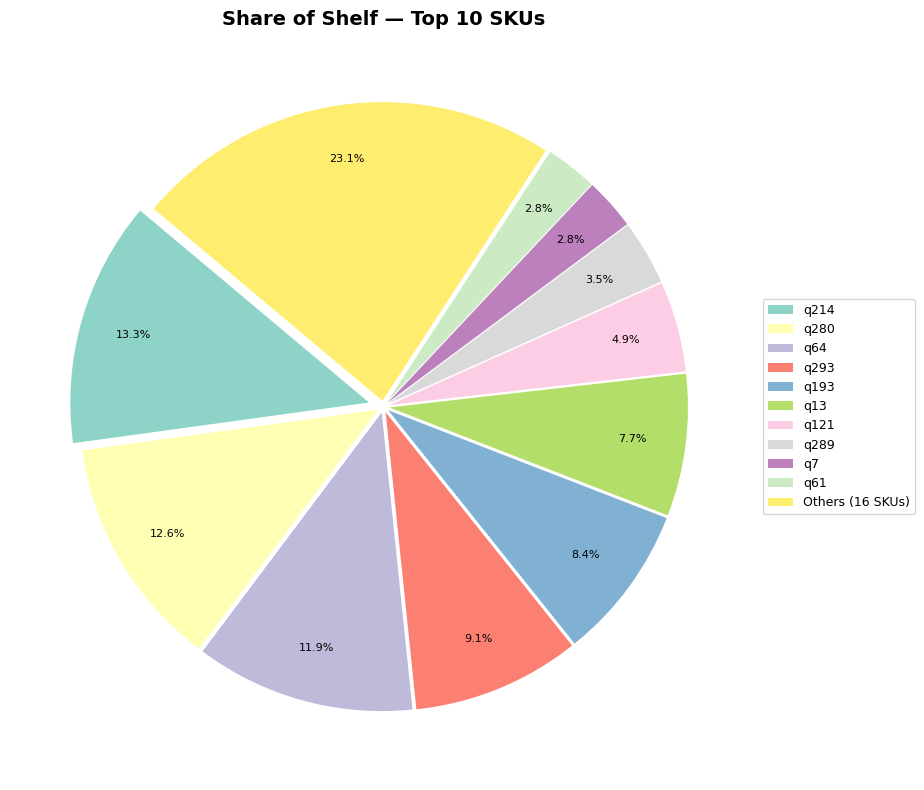

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

top_n    = 10
top_df   = df_sos.head(top_n).copy()
rest_pct = df_sos["share_pct"].iloc[top_n:].sum()

rest_row = pd.DataFrame([{
    "class_name": f"Others ({len(df_sos)-top_n} SKUs)",
    "share_pct" : round(rest_pct, 2)
}])
pie_df = pd.concat([top_df[["class_name","share_pct"]], rest_row], ignore_index=True)

colors_pie = cm.Set3(np.linspace(0, 1, len(pie_df)))
explode    = [0.05 if i == 0 else 0.02 for i in range(len(pie_df))]

wedges, texts, autotexts = ax.pie(
    pie_df["share_pct"],
    autopct     = "%1.1f%%",
    startangle  = 140,
    explode     = explode,
    colors      = colors_pie,
    pctdistance = 0.82,
)
for t in autotexts:
    t.set_fontsize(8)

ax.legend(wedges, pie_df["class_name"],
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)
ax.set_title("Share of Shelf — Top 10 SKUs",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("share_of_shelf_pie.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
df_sos.to_csv("share_of_shelf_results.csv", index=False)
print("✅ Saved share_of_shelf_results.csv")

✅ Saved share_of_shelf_results.csv


In [12]:
print("=" * 55)
print("          FINAL PROJECT SUMMARY")
print("=" * 55)
print()
print("  ── Model Performance ──────────────────────────")
print(f"  Baseline Recall      : 67.6%")
print(f"  Our Recall           : 73.7%  (+6.1pp) ✅")
print(f"  Our Precision        : 78.4%")
print(f"  F1 Score             : 76.0%")
print(f"  mAP50                : 77.9%")
print(f"  Confidence Threshold : 0.70")
print(f"  TTA                  : Enabled")
print()
print("  ── Detection Accuracy ─────────────────────────")
print(f"  Ground Truth         : 145 products")
print(f"  Our Detections       : 143 products")
print(f"  Accuracy             : 98.6% count accuracy ✅")
print()
print("  ── Model Config ───────────────────────────────")
print(f"  Architecture         : YOLOv11x")
print(f"  Epochs               : 150")
print(f"  Image size           : 640")
print(f"  Batch size           : 32")
print(f"  GPU                  : H100 80GB")
print()
print("  ── Share of Shelf ─────────────────────────────")
print(f"  Test images          : 35")
print(f"  Total detections     : {total_detections}")
print(f"  Unique SKUs found    : {len(df_sos)} / 76")
print(f"  #1 SKU               : {df_sos.iloc[0]['class_name']}  — {df_sos.iloc[0]['share_pct']}%")
print(f"  #2 SKU               : {df_sos.iloc[1]['class_name']}  — {df_sos.iloc[1]['share_pct']}%")
print(f"  #3 SKU               : {df_sos.iloc[2]['class_name']}  — {df_sos.iloc[2]['share_pct']}%")
print("=" * 55)

          FINAL PROJECT SUMMARY

  ── Model Performance ──────────────────────────
  Baseline Recall      : 67.6%
  Our Recall           : 73.7%  (+6.1pp) ✅
  Our Precision        : 78.4%
  F1 Score             : 76.0%
  mAP50                : 77.9%
  Confidence Threshold : 0.70
  TTA                  : Enabled

  ── Detection Accuracy ─────────────────────────
  Ground Truth         : 145 products
  Our Detections       : 143 products
  Accuracy             : 98.6% count accuracy ✅

  ── Model Config ───────────────────────────────
  Architecture         : YOLOv11x
  Epochs               : 150
  Image size           : 640
  Batch size           : 32
  GPU                  : H100 80GB

  ── Share of Shelf ─────────────────────────────
  Test images          : 35
  Total detections     : 143
  Unique SKUs found    : 26 / 76
  #1 SKU               : q214  — 13.29%
  #2 SKU               : q280  — 12.59%
  #3 SKU               : q64  — 11.89%
